# Comparison EDA - UCI Adult (1994) vs ACS PUMS (2024)

No new statistical computation. Reads the summary tables exported by notebooks 01 and 02 from `results/tables/`, stacks each UCI/ACS pair, and presents the four cross-dataset comparisons that the modelling analysis builds on:

1. Class balance - the share earning above the income threshold in each dataset.
2. Proxy attributes - which features carry the protected attributes, and how that shifted.
3. Income gap by sex - raw gap, controlled gaps, and the threshold sensitivity check.
4. Income gap by race - group rates and the change in cluster structure.

Every figure is read from a committed CSV, so each number traces back to the notebook that produced it. Charts are saved to `results/figures/`.

## 0. Setup

Only reading and plotting libraries are needed; no statistics are recomputed. Results and figures directories are resolved relative to this notebook so paths hold from a clean clone.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

RESULTS_DIR = "../results/tables"
FIGURES_DIR = "../results/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Fixed colours so UCI and ACS read consistently across every chart.
COLOURS = {"UCI Adult (1994)": "#4C72B0", "ACS PUMS (2024)": "#DD8452"}

print("files present:")
print(sorted(f for f in os.listdir(RESULTS_DIR) if f.endswith(".csv")))

files present:
['acs_ci_baseline.csv', 'acs_intersectional.csv', 'acs_model_results.csv', 'acs_multiseed_results.csv', 'acs_multiseed_summary.csv', 'acs_proxy_strength.csv', 'acs_race_binarisation.csv', 'acs_race_pairwise_tests.csv', 'acs_sex_gap_controls.csv', 'acs_threshold_results.csv', 'acs_threshold_sensitivity.csv', 'uci_ci_baseline.csv', 'uci_intersectional.csv', 'uci_model_results.csv', 'uci_proxy_strength.csv', 'uci_race_binarisation.csv', 'uci_race_pairwise_tests.csv', 'uci_sex_gap_controls.csv']


## 1. Class balance

The share of records above the income threshold. These two figures are stated as constants
from the notebook summaries rather than read from a CSV. It is the one comparison here that
is not auto-derived.

The contrast is large (76/24 against 49/51) but is driven by the fixed nominal $50,000
threshold, not a change in the population.

In [ ]:
# Stated from the notebook 01 and 02 summaries, not read from CSV
class_balance = pd.DataFrame({
    "dataset": ["UCI Adult (1994)", "ACS PUMS (2024)"],
    "above_threshold_pct": [23.9, 49.08],
    "below_threshold_pct": [76.1, 50.92],
})
class_balance

,dataset,above_threshold_pct,below_threshold_pct
0,UCI Adult (1994),23.90,76.10
1,ACS PUMS (2024),49.08,50.92


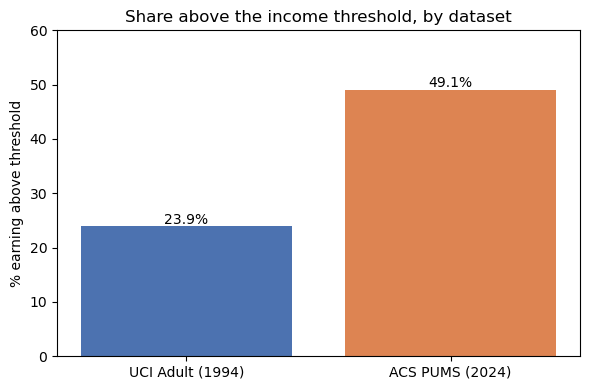

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(class_balance["dataset"], class_balance["above_threshold_pct"],
       color=[COLOURS[d] for d in class_balance["dataset"]])
ax.set_ylabel("% earning above threshold")
ax.set_title("Share above the income threshold, by dataset")
for i, v in enumerate(class_balance["above_threshold_pct"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")
ax.set_ylim(0, 60)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/class_balance.png", dpi=150)
plt.show()

### Findings - class balance

The share earning above the `>50K` threshold is 23.9% in 1994 against 49.1% in 2024. This is driven by the fixed nominal $50k threshold, not a population change, the same dollar figure selects the top quarter of 1994 earners but roughly half of 2024 earners. Section 3 tests the consequence for the sex gap.

## 2. Proxy attributes

The two `*_proxy_strength.csv` tables hold the Cramér's V association between each feature and
protected attribute. They are written with feature name in the index column, so they
are read with `index_col=0`. The two datasets are stacked and shown side by side for the two
protected attributes in turn.

In [4]:
proxy_uci = pd.read_csv(f"{RESULTS_DIR}/uci_proxy_strength.csv", index_col=0)
proxy_acs = pd.read_csv(f"{RESULTS_DIR}/acs_proxy_strength.csv", index_col=0)

# Each file has columns: cramers_v_sex, cramers_v_race, dataset (indexed by feature).
proxy_sex_cmp = pd.DataFrame({
    "UCI Adult (1994)": proxy_uci["cramers_v_sex"],
    "ACS PUMS (2024)": proxy_acs["cramers_v_sex"],
}).sort_values("UCI Adult (1994)", ascending=False)

proxy_race_cmp = pd.DataFrame({
    "UCI Adult (1994)": proxy_uci["cramers_v_race"],
    "ACS PUMS (2024)": proxy_acs["cramers_v_race"],
}).sort_values("UCI Adult (1994)", ascending=False)

print("association with SEX (Cramer's V):")
print(proxy_sex_cmp.round(3))
print()
print("association with RACE (Cramer's V):")
print(proxy_race_cmp.round(3))

association with SEX (Cramer's V):
                UCI Adult (1994)  ACS PUMS (2024)
relationship               0.647            0.075
marital-status             0.459            0.104
occupation                 0.424            0.451
income                     0.215            0.138
workclass                  0.152            0.161
race                       0.114            0.032
education                  0.093            0.108
native-country             0.061              NaN
birthplace-us                NaN            0.012
sex                          NaN              NaN

association with RACE (Cramer's V):
                UCI Adult (1994)  ACS PUMS (2024)
native-country             0.402              NaN
sex                        0.114            0.032
income                     0.100            0.146
relationship               0.098            0.096
marital-status             0.083            0.082
occupation                 0.079            0.116
education                  0

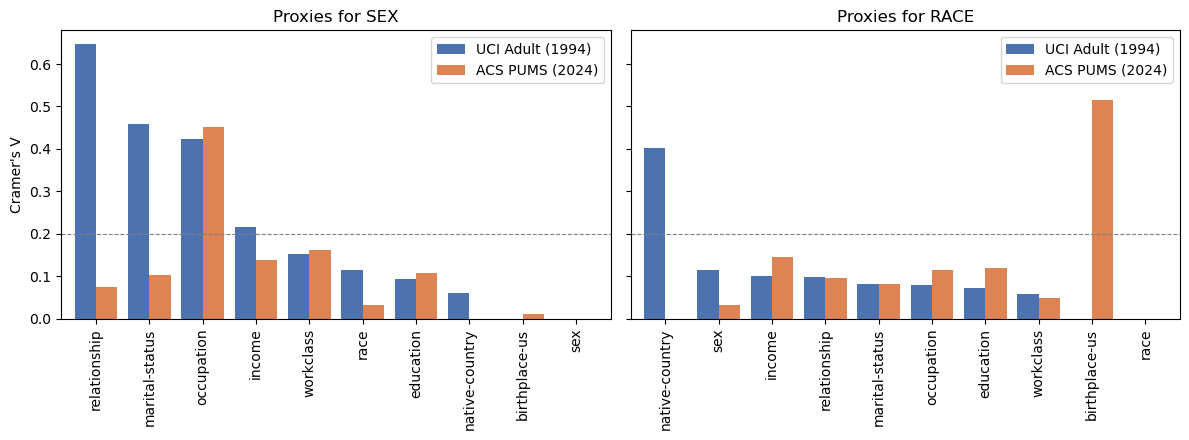

In [5]:
# The relationship-proxy collapse for sex is the headline shift, so it is charted.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, (cmp, title) in zip(axes, [(proxy_sex_cmp, "Proxies for SEX"),
                                   (proxy_race_cmp, "Proxies for RACE")]):
    cmp.plot(kind="bar", ax=ax, color=[COLOURS[c] for c in cmp.columns], width=0.8)
    ax.set_title(title)
    ax.set_ylabel("Cramer's V")
    ax.set_xlabel("")
    ax.axhline(0.2, color="grey", linestyle="--", linewidth=0.8)
    ax.legend(title="")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/proxy_strength.png", dpi=150)
plt.show()

### Findings: proxy attributes

(a) `relationship` falls from the strongest sex proxy in 1994 (Cramér's V = 0.647) to negligible in 2024 (0.075), coinciding with the `RELP` to `RELSHIPP` coding change (flagged as tentative, not purely social). (b) `occupation` is the strongest sex proxy in 2024 (0.451); `birthplace-us`/`native-country` remains the strongest race proxy. (c) So the feature removed with each protected attribute differs by dataset: `relationship`/`native-country` in UCI, `occupation`/`birthplace-us` in ACS.

## 3. Income gap by sex

Two tables feed this section. The `*_sex_gap_controls.csv` files hold the raw gap and the gap
remaining after each control. The `acs_threshold_sensitivity.csv` file holds the
nominal-vs-adjusted threshold result, for ACS only: UCI carries no dollar amounts and cannot
be re-thresholded.

In [6]:
controls_uci = pd.read_csv(f"{RESULTS_DIR}/uci_sex_gap_controls.csv")
controls_acs = pd.read_csv(f"{RESULTS_DIR}/acs_sex_gap_controls.csv")

controls_cmp = pd.concat([controls_uci, controls_acs], ignore_index=True)
# Show the two datasets side by side on % of raw gap remaining, per control.
controls_pivot = controls_cmp.pivot(index="control", columns="dataset",
                                    values="pct_of_raw_gap")
print(controls_pivot.round(1))

dataset                               ACS PUMS (2024)  UCI Adult (1994)
control                                                                
hours worked                                     49.7              78.4
none (raw)                                      100.0             100.0
occupation                                       99.5              95.6
relationship (small groups excluded)            109.6              19.9


In [7]:
sensitivity = pd.read_csv(f"{RESULTS_DIR}/acs_threshold_sensitivity.csv")
print("threshold sensitivity (ACS only):")
print(sensitivity.round(2))
print()
print("The ratio is the fairness-relevant column: point-gaps compress at a harder threshold")
print("because base rates fall, so the ratio is what shows whether disparity actually widens.")

threshold sensitivity (ACS only):
           threshold  male_pct  female_pct  gap_pct_points  ratio          dataset
0    nominal $50,000     55.70       41.91           13.79   1.33  ACS PUMS (2024)
1  adjusted $105,833     22.83       12.44           10.40   1.84  ACS PUMS (2024)

The ratio is the fairness-relevant column: point-gaps compress at a harder threshold
because base rates fall, so the ratio is what shows whether disparity actually widens.


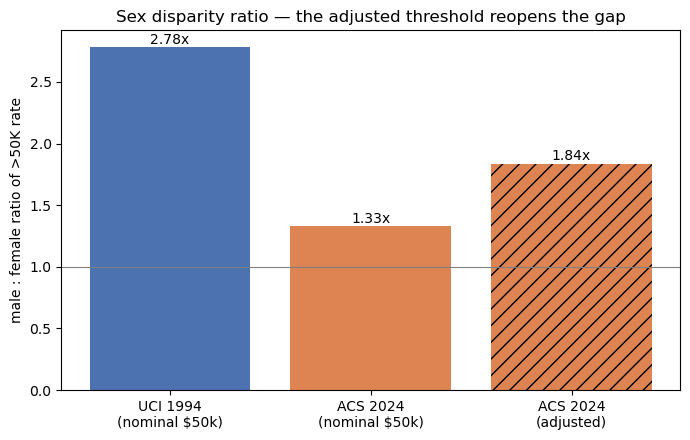

In [8]:
# Sex ratio comparison: UCI raw, ACS nominal, ACS inflation-adjusted.
# UCI raw ratio (2.78) is stated from the notebook 01 summary; the ACS ratios are read above.
uci_ratio = 2.78
acs_nominal_ratio = sensitivity.loc[sensitivity["threshold"].str.contains("nominal"), "ratio"].iloc[0]
acs_adj_ratio = sensitivity.loc[sensitivity["threshold"].str.contains("adjusted"), "ratio"].iloc[0]

labels = ["UCI 1994\n(nominal $50k)", "ACS 2024\n(nominal $50k)", "ACS 2024\n(adjusted)"]
ratios = [uci_ratio, acs_nominal_ratio, acs_adj_ratio]
bar_colours = [COLOURS["UCI Adult (1994)"], COLOURS["ACS PUMS (2024)"], COLOURS["ACS PUMS (2024)"]]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, ratios, color=bar_colours)
bars[2].set_hatch("//")  # mark the adjusted bar as the sensitivity check
ax.axhline(1.0, color="grey", linewidth=0.8)
ax.set_ylabel("male : female ratio of >50K rate")
ax.set_title("Sex disparity ratio — the adjusted threshold reopens the gap")
for i, v in enumerate(ratios):
    ax.text(i, v + 0.03, f"{v:.2f}x", ha="center")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/sex_ratio_comparison.png", dpi=150)
plt.show()

### Findings: income gap by sex

(a) Occupation explains almost none of the gap in either dataset (99.5% / 95.6% remaining), while the relationship control behaves oppositely: it removes ~80% of the 1994 gap (19.9% remaining) but *widens* it in 2024 (109.6%), consistent with `relationship` having collapsed as a sex proxy. (b) Threshold sensitivity: the male/female ratio widens from 1.33 at the nominal $50k to 1.84 at the inflation-adjusted threshold, moving toward the 1994 figure of 2.78. Much of the apparent narrowing is therefore a threshold artefact. Limitation: this re-thresholds rather than rescaling the income distribution.

## 4. Income gap by race

Two tables feed this section. The `*_race_pairwise_tests.csv` files hold every pairwise
two-proportion test between race groups (written with `index=False`). The
`*_race_binarisation.csv` files hold the White-vs-rest and cluster groupings (written with the
grouping name in the index column). The change worth surfacing is structural: UCI shows two
clusters, ACS does not.

In [9]:
tests_uci = pd.read_csv(f"{RESULTS_DIR}/uci_race_pairwise_tests.csv")
tests_acs = pd.read_csv(f"{RESULTS_DIR}/acs_race_pairwise_tests.csv")

# Count how many pairs are statistically indistinguishable in each dataset — the UCI
# two-cluster structure shows up as several 'same' verdicts; ACS as almost none.
print("UCI pairwise verdicts:")
print(tests_uci["verdict"].value_counts())
print()
print("ACS pairwise verdicts:")
print(tests_acs["verdict"].value_counts())
print()
print("UCI pairs judged 'same' (the two-cluster signal):")
print(tests_uci.loc[tests_uci["verdict"] == "same", ["group_1", "group_2", "p_value"]])
print()
print("ACS pairs judged 'same':")
print(tests_acs.loc[tests_acs["verdict"] == "same", ["group_1", "group_2", "p_value"]])

UCI pairwise verdicts:
verdict
DIFFERENT    6
same         4
Name: count, dtype: int64

ACS pairwise verdicts:
verdict
DIFFERENT    9
same         1
Name: count, dtype: int64

UCI pairs judged 'same' (the two-cluster signal):
              group_1 group_2   p_value
6  Asian-Pac-Islander   White  0.179592
7  Amer-Indian-Eskimo   Other  0.780540
8  Amer-Indian-Eskimo   Black  0.809842
9               Black   Other  0.889619

ACS pairs judged 'same':
              group_1 group_2   p_value
9  Amer-Indian-Eskimo   Other  0.076433


In [10]:
binar_uci = pd.read_csv(f"{RESULTS_DIR}/uci_race_binarisation.csv", index_col=0)
binar_acs = pd.read_csv(f"{RESULTS_DIR}/acs_race_binarisation.csv", index_col=0)

# Compare the race_binary (White vs Non-White) disparity ratio across datasets.
binar_cmp = pd.DataFrame({
    "UCI Adult (1994)": binar_uci.loc["race_binary"],
    "ACS PUMS (2024)": binar_acs.loc["race_binary"],
})
print(binar_cmp)

                        UCI Adult (1994)  ACS PUMS (2024)
advantaged                         White            White
advantaged_rate_pct                 25.4            53.04
disadvantaged                  Non-White        Non-White
disadvantaged_rate_pct             15.25            41.15
gap_pct_points                     10.14            11.89
ratio                              0.601            0.776
dataset                 UCI Adult (1994)  ACS PUMS (2024)


### Findings: income gap by race

(a) The UCI two-cluster structure does not persist. In 1994, White and Asian-Pac-Islander were statistically indistinguishable (p = 0.18) and formed a high cluster against the rest; in 2024, 9 of 10 pairs are distinguishable and Asian-Pac-Islander separates out. The larger 2024 sample separates groups more easily, so this carries a sample-size caveat. (b) The White / Non-White binary grouping is kept for cross-dataset consistency and recorded as a limitation, not a claim that the groups are internally homogeneous.

## 5. Summary

Four comparisons. Class balance is threshold-driven (23.9% vs 49.1%). The sex-gap narrowing is substantially a threshold artefact: the ratio recovers toward the 1994 value once the threshold is adjusted. The race two-cluster structure does not persist into 2024. The proxy features carrying each protected attribute differ between datasets. This hands the modelling notebooks `race_binary` as the protected race variable, plus the proxies to remove: `relationship`/`native-country` for UCI, `occupation`/`birthplace-us` for ACS.